<a href="https://colab.research.google.com/github/anamdias/anamdias/blob/main/Tech_Challenge_Meses_8_e_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# instalar biblioteca para ler arquivos Excel antigos (.xls)
!pip install xlrd

In [2]:
from google.colab import files

# abrir a janela para enviar os arquivos
uploaded = files.upload()

Saving Dicionario_PNAD_COVID_092020_20220621.xls to Dicionario_PNAD_COVID_092020_20220621.xls
Saving Dicionario_PNAD_COVID_082020_20220621.xls to Dicionario_PNAD_COVID_082020_20220621.xls
Saving PNAD_COVID_092020.zip to PNAD_COVID_092020.zip
Saving PNAD_COVID_082020.zip to PNAD_COVID_082020.zip


In [3]:
import os

# listar os arquivos que estão disponíveis no ambiente
print(os.listdir())

['.config', 'Dicionario_PNAD_COVID_082020_20220621.xls', 'Dicionario_PNAD_COVID_092020_20220621.xls', 'PNAD_COVID_092020.zip', 'PNAD_COVID_082020.zip', 'sample_data']


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# ler o dicionário de setembro usando a linha 6 como cabeçalho
dic = pd.read_excel(
    "Dicionario_PNAD_COVID_092020_20220621.xls",
    header=5
)

# mostrar as primeiras linhas
dic.head()

,2,UF,Unnamed: 2,Unidade da Federação,11,Rondônia
0,NaN,NaN,NaN,NaN,12,Acre
1,NaN,NaN,NaN,NaN,13,Amazonas
2,NaN,NaN,NaN,NaN,14,Roraima
3,NaN,NaN,NaN,NaN,15,Pará
4,NaN,NaN,NaN,NaN,16,Amapá


In [8]:
# ler o dicionário de setembro usando a linha 3 como cabeçalho
dic = pd.read_excel(
    "Dicionario_PNAD_COVID_092020_20220621.xls",
    header=2
)

# mostrar as primeiras linhas
dic.head()

,Unnamed: 0,Unnamed: 1,nº,Descrição,Tipo,Descrição.1
0,Parte 1 - Identificação e Controle,NaN,NaN,NaN,NaN,NaN
1,4,Ano,NaN,Ano de referência,NaN,NaN
2,2,UF,NaN,Unidade da Federação,11,Rondônia
3,NaN,NaN,NaN,NaN,12,Acre
4,NaN,NaN,NaN,NaN,13,Amazonas


In [9]:
# mostrar os nomes das colunas do dicionário
print(dic.columns.tolist())

['Unnamed: 0', 'Unnamed: 1', 'nº', 'Descrição', 'Tipo ', 'Descrição.1']


In [10]:
# renomear colunas do dicionário para facilitar a análise
dic.columns = [
    "tamanho",
    "codigo_variavel",
    "numero_valor",
    "descricao_variavel",
    "tipo",
    "descricao_valor"
]

# visualizar novamente
dic.head()

,tamanho,codigo_variavel,numero_valor,descricao_variavel,tipo,descricao_valor
0,Parte 1 - Identificação e Controle,NaN,NaN,NaN,NaN,NaN
1,4,Ano,NaN,Ano de referência,NaN,NaN
2,2,UF,NaN,Unidade da Federação,11,Rondônia
3,NaN,NaN,NaN,NaN,12,Acre
4,NaN,NaN,NaN,NaN,13,Amazonas


In [11]:
# mostrar informações da variável B0011
dic[dic["codigo_variavel"] == "B0011"]

,tamanho,codigo_variavel,numero_valor,descricao_variavel,tipo,descricao_valor
157,1,B0011,B1,Na semana passada teve febre?,1,Sim


In [12]:
# mostrar algumas variáveis importantes
dic[dic["codigo_variavel"].isin(["B0011", "B002", "B005", "C001", "D001"])][
    ["codigo_variavel", "descricao_variavel", "numero_valor", "descricao_valor"]
]

,codigo_variavel,descricao_variavel,numero_valor,descricao_valor
157,B0011,Na semana passada teve febre?,B1,Sim
209,B002,"Por causa disso, foi a algum estabelecimento d...",B2,Sim
265,B005,"Ao procurar o hospital, teve que ficar interna...",B5,Sim
331,C001,"Na semana passada, por pelo menos uma hora, tr...",C1,Sim


In [14]:
# ler os dados de agosto
aug = pd.read_csv("PNAD_COVID_082020.zip", sep=";", encoding="latin1")

# ler os dados de setembro
sep = pd.read_csv("PNAD_COVID_092020.zip", sep=";", encoding="latin1")

In [15]:
# mostrar tamanho das tabelas
print("Agosto:", aug.shape)
print("Setembro:", sep.shape)

# mostrar as primeiras linhas de agosto
aug.head()

Agosto: (386520, 1)
Setembro: (387298, 1)


,"Ano,UF,CAPITAL,RM_RIDE,V1008,V1012,V1013,V1016,Estrato,UPA,V1022,V1023,V1030,V1031,V1032,posest,A001,A001A,A001B1,A001B2,A001B3,A002,A003,A004,A005,A006,A007,A008,A009,B0011,B0012,B0013,B0014,B0015,B0016,B0017,B0018,B0019,B00110,B00111,B00112,B00113,B002,B0031,B0032,B0033,B0034,B0035,B0036,B0037,B0041,B0042,B0043,B0044,B0045,B0046,B005,B006,B007,B008,B009A,B009B,B009C,B009D,B009E,B009F,B0101,B0102,B0103,B0104,B0105,B0106,B011,C001,C002,C003,C004,C005,C0051,C0052,C0053,C006,C007,C007A,C007B,C007C,C007D,C007E,C007E1,C007E2,C007F,C008,C009,C009A,C010,C0101,C01011,C01012,C0102,C01021,C01022,C0103,C0104,C011A,C011A1,C011A11,C011A12,C011A2,C011A21,C011A22,C012,C013,C014,C015,C016,C017A,D0011,D0013,D0021,D0023,D0031,D0033,D0041,D0043,D0051,D0053,D0061,D0063,D0071,D0073,E001,E0021,E0022,E0023,E0024,F001,F0021,F0022,F002A1,F002A2,F002A3,F002A4,F002A5,F0061,F006"
0,"2020,11,11,,01,4,08,4,1110011,110015970,1,1,15..."
1,"2020,11,11,,01,4,08,4,1110011,110015970,1,1,15..."
2,"2020,11,11,,01,4,08,4,1110011,110015970,1,1,14..."
3,"2020,11,11,,01,4,08,4,1110011,110015970,1,1,14..."
4,"2020,11,11,,02,1,08,4,1110011,110015970,1,1,91..."


In [17]:
# ler os dados de agosto
aug = pd.read_csv("PNAD_COVID_082020.zip")

# ler os dados de setembro
sep = pd.read_csv("PNAD_COVID_092020.zip")

In [19]:
aug = pd.read_csv("PNAD_COVID_082020.zip", encoding="latin1")
sep = pd.read_csv("PNAD_COVID_092020.zip", encoding="latin1")

In [20]:
print(aug.shape)
print(sep.shape)

aug.head()

(386520, 145)
(387298, 145)


,Ano,UF,CAPITAL,RM_RIDE,V1008,V1012,V1013,V1016,Estrato,UPA,...,F001,F0021,F0022,F002A1,F002A2,F002A3,F002A4,F002A5,F0061,F006
0,2020,11,11.0,NaN,1,4,8,4,1110011,110015970,...,1,NaN,NaN,1,1,1,2,1,1,1.0
1,2020,11,11.0,NaN,1,4,8,4,1110011,110015970,...,1,NaN,NaN,1,1,1,2,1,1,1.0
2,2020,11,11.0,NaN,1,4,8,4,1110011,110015970,...,1,NaN,NaN,1,1,1,2,1,1,1.0
3,2020,11,11.0,NaN,1,4,8,4,1110011,110015970,...,1,NaN,NaN,1,1,1,2,1,1,1.0
4,2020,11,11.0,NaN,2,1,8,4,1110011,110015970,...,1,NaN,NaN,1,1,1,2,1,1,1.0


In [21]:
aug["MES"] = "2020-08"
sep["MES"] = "2020-09"

df = pd.concat([aug, sep], ignore_index=True)

print(df.shape)

(773818, 146)


In [22]:
# listar os nomes das colunas do arquivo de agosto
print(aug.columns.tolist())

['Ano', 'UF', 'CAPITAL', 'RM_RIDE', 'V1008', 'V1012', 'V1013', 'V1016', 'Estrato', 'UPA', 'V1022', 'V1023', 'V1030', 'V1031', 'V1032', 'posest', 'A001', 'A001A', 'A001B1', 'A001B2', 'A001B3', 'A002', 'A003', 'A004', 'A005', 'A006', 'A007', 'A008', 'A009', 'B0011', 'B0012', 'B0013', 'B0014', 'B0015', 'B0016', 'B0017', 'B0018', 'B0019', 'B00110', 'B00111', 'B00112', 'B00113', 'B002', 'B0031', 'B0032', 'B0033', 'B0034', 'B0035', 'B0036', 'B0037', 'B0041', 'B0042', 'B0043', 'B0044', 'B0045', 'B0046', 'B005', 'B006', 'B007', 'B008', 'B009A', 'B009B', 'B009C', 'B009D', 'B009E', 'B009F', 'B0101', 'B0102', 'B0103', 'B0104', 'B0105', 'B0106', 'B011', 'C001', 'C002', 'C003', 'C004', 'C005', 'C0051', 'C0052', 'C0053', 'C006', 'C007', 'C007A', 'C007B', 'C007C', 'C007D', 'C007E', 'C007E1', 'C007E2', 'C007F', 'C008', 'C009', 'C009A', 'C010', 'C0101', 'C01011', 'C01012', 'C0102', 'C01021', 'C01022', 'C0103', 'C0104', 'C011A', 'C011A1', 'C011A11', 'C011A12', 'C011A2', 'C011A21', 'C011A22', 'C012', 'C0

In [23]:
# criar coluna para identificar o mês
aug["MES"] = "2020-08"
sep["MES"] = "2020-09"

In [24]:
# juntar os dois meses em um único dataframe
df = pd.concat([aug, sep], ignore_index=True)

# mostrar quantidade de linhas e colunas
print("Base final:", df.shape)

Base final: (773818, 146)


In [25]:
# lista das variáveis escolhidas
variaveis_importantes = [
    "B0011",
    "B0012",
    "B0013",
    "B0014",
    "B0015",
    "B0019",
    "B00110",
    "B002",
    "B005",
    "C001",
    "D001"
]

In [26]:
# verificar quais colunas existem
colunas_encontradas = [col for col in variaveis_importantes if col in df.columns]
colunas_nao_encontradas = [col for col in variaveis_importantes if col not in df.columns]

print("Encontradas:", colunas_encontradas)
print("Não encontradas:", colunas_nao_encontradas)

Encontradas: ['B0011', 'B0012', 'B0013', 'B0014', 'B0015', 'B0019', 'B00110', 'B002', 'B005', 'C001']
Não encontradas: ['D001']


In [27]:
# criar dataframe apenas com as variáveis de interesse + mês
df_analise = df[variaveis_importantes + ["MES"]].copy()

# mostrar primeiras linhas
df_analise.head()

KeyError: "['D001'] not in index"

In [28]:
[col for col in df.columns if "D00" in col]

['D0011',
 'D0013',
 'D0021',
 'D0023',
 'D0031',
 'D0033',
 'D0041',
 'D0043',
 'D0051',
 'D0053',
 'D0061',
 'D0063',
 'D0071',
 'D0073']

In [29]:
[col for col in df.columns if "aux" in col.lower()]

[]

In [30]:
dic[dic["descricao_variavel"].str.contains("aux", case=False, na=False)]

,tamanho,codigo_variavel,numero_valor,descricao_variavel,tipo,descricao_valor
573,1,D0051,D1,Auxílios emergenciais relacionados ao coronavirus,1,Sim


In [31]:
dic[dic["descricao_variavel"].str.contains("renda", case=False, na=False)]

,tamanho,codigo_variavel,numero_valor,descricao_variavel,tipo,descricao_valor
581,1,D0071,D1,"Outros rendimentos, como aluguel, arrendamento...",1,Sim


In [32]:
# lista das variáveis escolhidas

variaveis_importantes = [
    "B0011",  # febre
    "B0012",  # tosse
    "B0013",  # dor de garganta
    "B0014",  # dificuldade respiratória
    "B0015",  # dor de cabeça
    "B0019",  # fadiga
    "B00110", # perda de olfato/paladar

    "B002",   # procurou atendimento médico
    "B005",   # fez teste de COVID

    "C001"    # trabalhou na semana
]

In [33]:
# verificar se as colunas existem no dataset

colunas_encontradas = [col for col in variaveis_importantes if col in df.columns]
colunas_nao_encontradas = [col for col in variaveis_importantes if col not in df.columns]

print("Encontradas:", colunas_encontradas)
print("Não encontradas:", colunas_nao_encontradas)

Encontradas: ['B0011', 'B0012', 'B0013', 'B0014', 'B0015', 'B0019', 'B00110', 'B002', 'B005', 'C001']
Não encontradas: []


In [34]:
# criar dataframe apenas com as variáveis escolhidas

df_analise = df[variaveis_importantes + ["MES"]].copy()

df_analise.head()

,B0011,B0012,B0013,B0014,B0015,B0019,B00110,B002,B005,C001,MES
0,2,2,2,2,2,2,2,NaN,NaN,1.0,2020-08
1,2,2,2,2,2,2,2,NaN,NaN,1.0,2020-08
2,2,2,2,2,2,2,2,NaN,NaN,NaN,2020-08
3,2,2,2,2,2,2,2,NaN,NaN,NaN,2020-08
4,2,2,2,2,2,2,2,NaN,NaN,2.0,2020-08


In [35]:
# variáveis de sintomas

sintomas = [
    "B0011",
    "B0012",
    "B0013",
    "B0014",
    "B0015",
    "B0019",
    "B00110"
]

In [36]:
# criar coluna indicando se a pessoa teve pelo menos um sintoma

df_analise["tem_sintoma"] = df_analise[sintomas].eq(1).any(axis=1)

df_analise.head()

,B0011,B0012,B0013,B0014,B0015,B0019,B00110,B002,B005,C001,MES,tem_sintoma
0,2,2,2,2,2,2,2,NaN,NaN,1.0,2020-08,False
1,2,2,2,2,2,2,2,NaN,NaN,1.0,2020-08,False
2,2,2,2,2,2,2,2,NaN,NaN,NaN,2020-08,False
3,2,2,2,2,2,2,2,NaN,NaN,NaN,2020-08,False
4,2,2,2,2,2,2,2,NaN,NaN,2.0,2020-08,False


In [37]:
# filtrar apenas pessoas com sintomas

sintomaticos = df_analise[df_analise["tem_sintoma"] == True]

print("Quantidade de sintomáticos:", sintomaticos.shape[0])

Quantidade de sintomáticos: 31688


In [38]:
percentual_sintomas = df_analise["tem_sintoma"].mean() * 100

print(f"1. {percentual_sintomas:.2f}% da população apresentou sintomas")

1. 4.10% da população apresentou sintomas


In [39]:
percentual_atendimento = (sintomaticos["B002"] == 1).mean() * 100

print(f"2. {percentual_atendimento:.2f}% dos sintomáticos procuraram atendimento médico")

2. 26.63% dos sintomáticos procuraram atendimento médico


In [40]:
percentual_teste = (sintomaticos["B005"] == 1).mean() * 100

print(f"3. {percentual_teste:.2f}% dos sintomáticos fizeram teste de COVID")

3. 1.34% dos sintomáticos fizeram teste de COVID


In [41]:
percentual_trabalho = (df_analise["C001"] == 1).mean() * 100

print(f"4. {percentual_trabalho:.2f}% da população continuou trabalhando")

4. 35.84% da população continuou trabalhando


In [42]:
comparacao_mes = df_analise.groupby("MES")["tem_sintoma"].mean() * 100

print(comparacao_mes.round(2))

MES
2020-08    4.70
2020-09    3.49
Name: tem_sintoma, dtype: float64


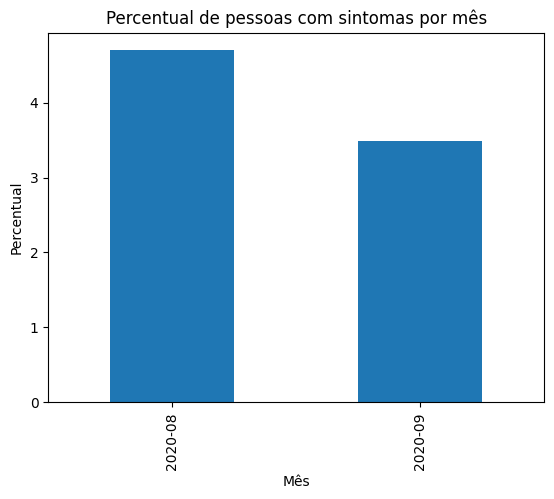

In [43]:
import matplotlib.pyplot as plt

comparacao_mes.plot(kind="bar")

plt.title("Percentual de pessoas com sintomas por mês")
plt.xlabel("Mês")
plt.ylabel("Percentual")

plt.show()

In [44]:
# calcular percentual de sintomáticos que continuaram trabalhando

percentual_trabalho_sintoma = (sintomaticos["C001"] == 1).mean() * 100

print(f"5. {percentual_trabalho_sintoma:.2f}% das pessoas com sintomas continuaram trabalhando")

5. 36.72% das pessoas com sintomas continuaram trabalhando


In [45]:
# calcular percentual de pessoas com sintomas por mês

sintomas_mes = df_analise.groupby("MES")["tem_sintoma"].mean() * 100

print(sintomas_mes.round(2))

MES
2020-08    4.70
2020-09    3.49
Name: tem_sintoma, dtype: float64
